In [58]:
# import libraries
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px 
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from xgboost import XGBRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import export_graphviz
from sklearn import tree
from IPython.display import SVG,display
from graphviz import Source
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
# Remove multicollinearity by using VIF technique
from statsmodels.stats.outliers_influence import variance_inflation_factor
import joblib
from pathlib import Path

# 1. Load Data 

In [3]:
# load dataset
df = pd.read_csv('car data.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


# 2. Exploratory Data Analysis

In [4]:
print("Number of rows are: ",df.shape[0])
print("Number of columns are: ",df.shape[1])

Number of rows are:  301
Number of columns are:  9


In [5]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [7]:
df.describe(include="all").round(2)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
count,301,301.00,301.00,301.00,301.00,301,301,301,301.00
unique,98,NaN,NaN,NaN,NaN,3,2,2,NaN
top,city,NaN,NaN,NaN,NaN,Petrol,Dealer,Manual,NaN
freq,26,NaN,NaN,NaN,NaN,239,195,261,NaN
mean,NaN,2013.63,4.66,7.63,36947.21,NaN,NaN,NaN,0.04
std,NaN,2.89,5.08,8.64,38886.88,NaN,NaN,NaN,0.25
min,NaN,2003.00,0.10,0.32,500.00,NaN,NaN,NaN,0.00
25%,NaN,2012.00,0.90,1.20,15000.00,NaN,NaN,NaN,0.00
50%,NaN,2014.00,3.60,6.40,32000.00,NaN,NaN,NaN,0.00
75%,NaN,2016.00,6.00,9.90,48767.00,NaN,NaN,NaN,0.00


In [8]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [9]:
print(f"Number of duplicated rows are:", df.duplicated().sum())

Number of duplicated rows are: 2


In [10]:
for i in df.columns.tolist():
  print("Number of unique values in",i,"is",df[i].nunique())

Number of unique values in Car_Name is 98
Number of unique values in Year is 16
Number of unique values in Selling_Price is 156
Number of unique values in Present_Price is 148
Number of unique values in Driven_kms is 206
Number of unique values in Fuel_Type is 3
Number of unique values in Selling_type is 2
Number of unique values in Transmission is 2
Number of unique values in Owner is 3


### 2.1. Categorical Variable Distribution

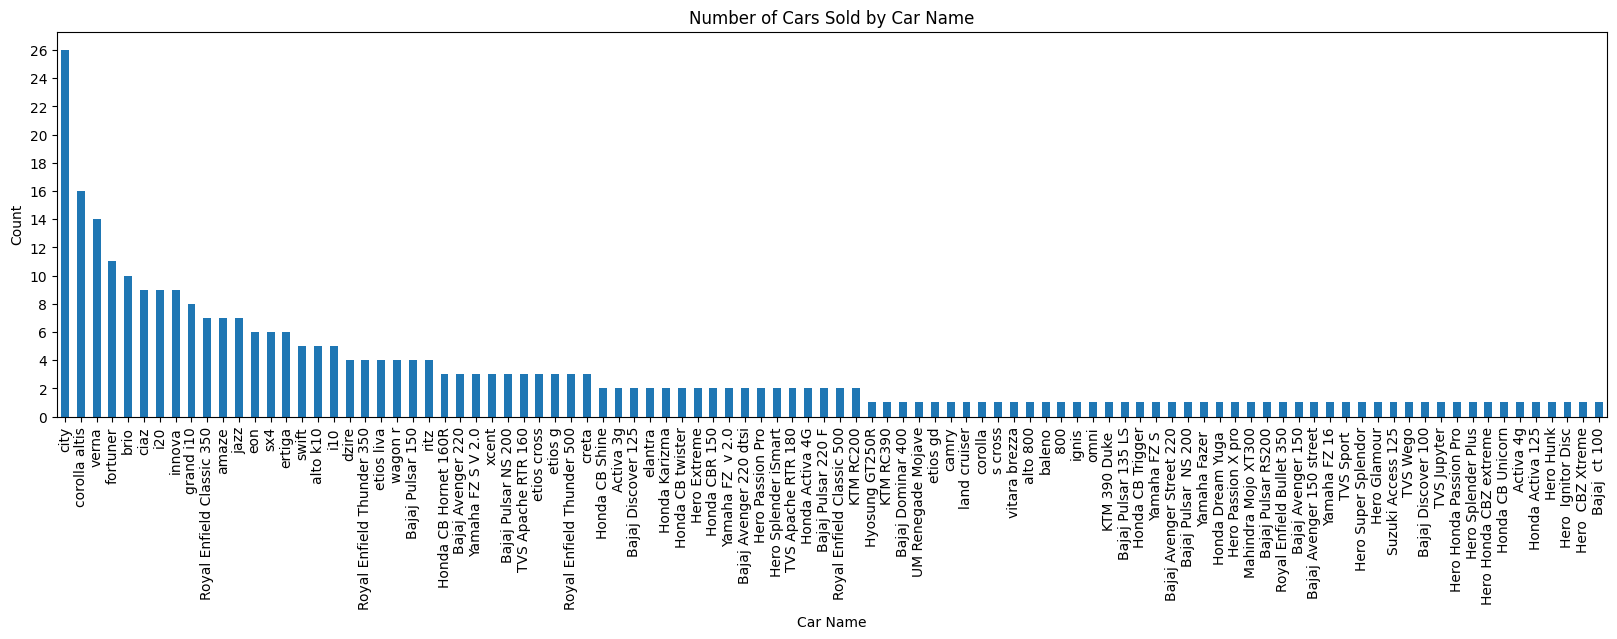

In [11]:
df['Car_Name'].value_counts().plot(kind='bar', figsize=(20,5))
plt.title("Number of Cars Sold by Car Name")
plt.xlabel("Car Name")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.yticks(range(0,28,2))
plt.show()


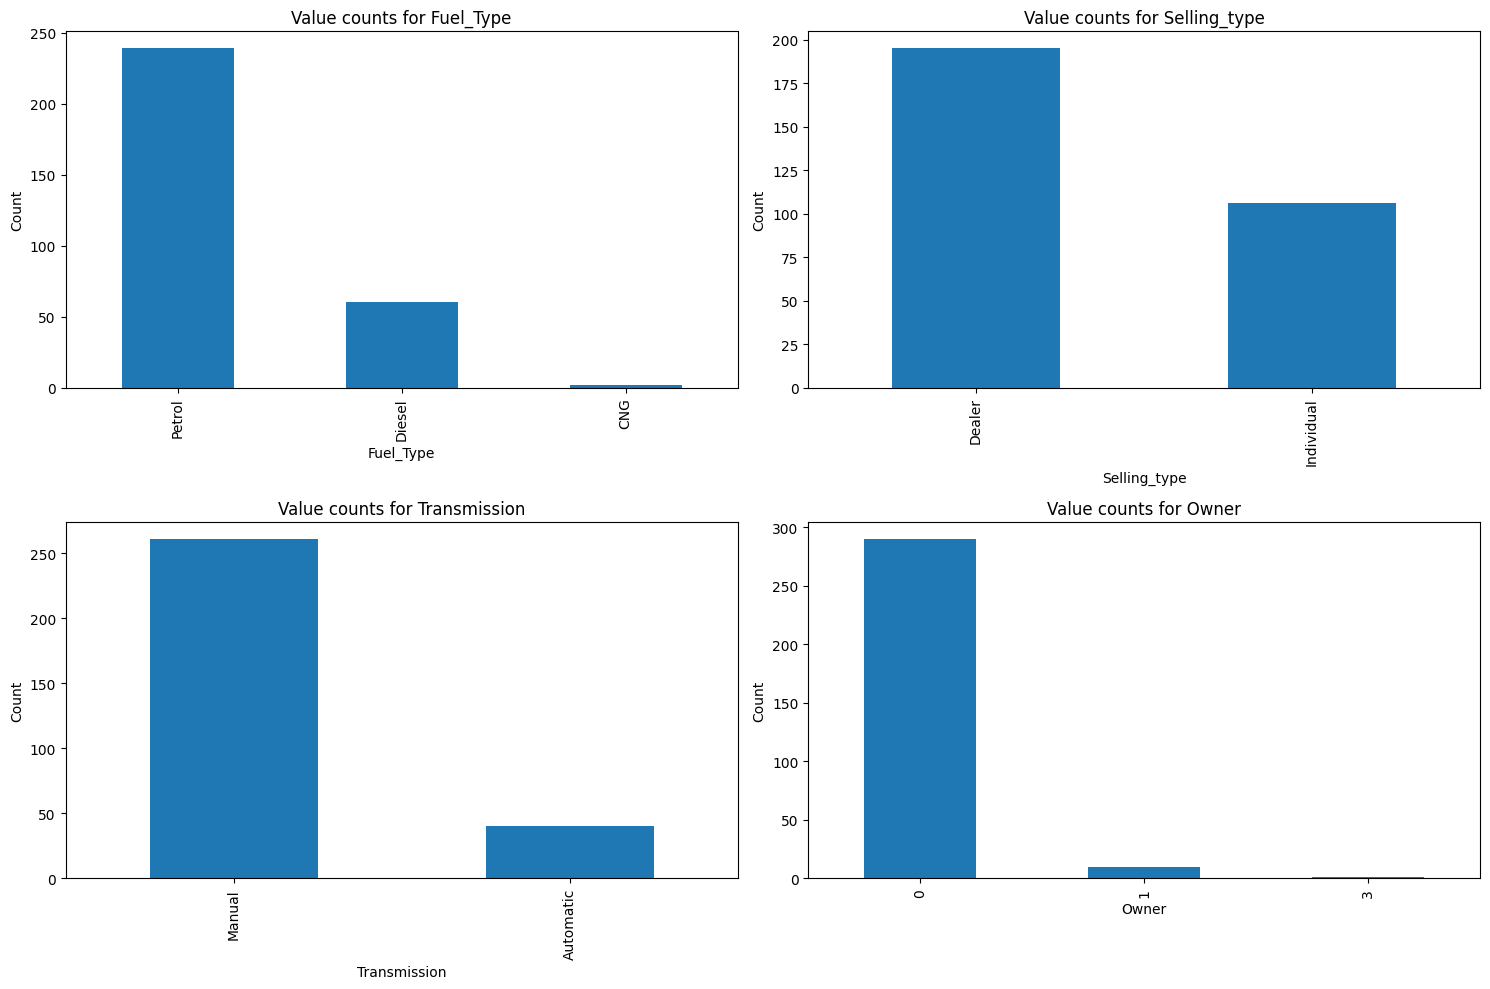

In [12]:
cat_cols = ['Fuel_Type', 'Selling_type', 'Transmission', 'Owner']
def plot_value_counts(df):
    fig, axes = plt.subplots(2, 2, figsize=(15,10))
    axes = axes.flatten()
    for i, col in enumerate(cat_cols):
        df[col].value_counts().plot(kind='bar', ax=axes[i])
        axes[i].set_title(f"Value counts for {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Count")
    plt.tight_layout()
    plt.show()
plot_value_counts(df)

From the above visualizations, the following insights can be drawn:
- Cars with Petrol as their fuel type are significantly more numerous compared to Diesel and CNG vehicles.
- A majority of cars are sold through Dealers, whereas sales by Individual sellers are comparatively lower.
- Manual transmission cars clearly outnumber Automatic transmission cars.
- Most vehicles are sold by First Owners, while sales by Third and Fourth Owners are minimal.

### 2.2. Adding 'car_age' Column

In [13]:
df['current_year'] = 2026
df['car_age'] = df['current_year'] - df['Year']
df.drop(['current_year'], axis=1, inplace=True )
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,car_age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


### 2.3. Numerical Variable Distribution

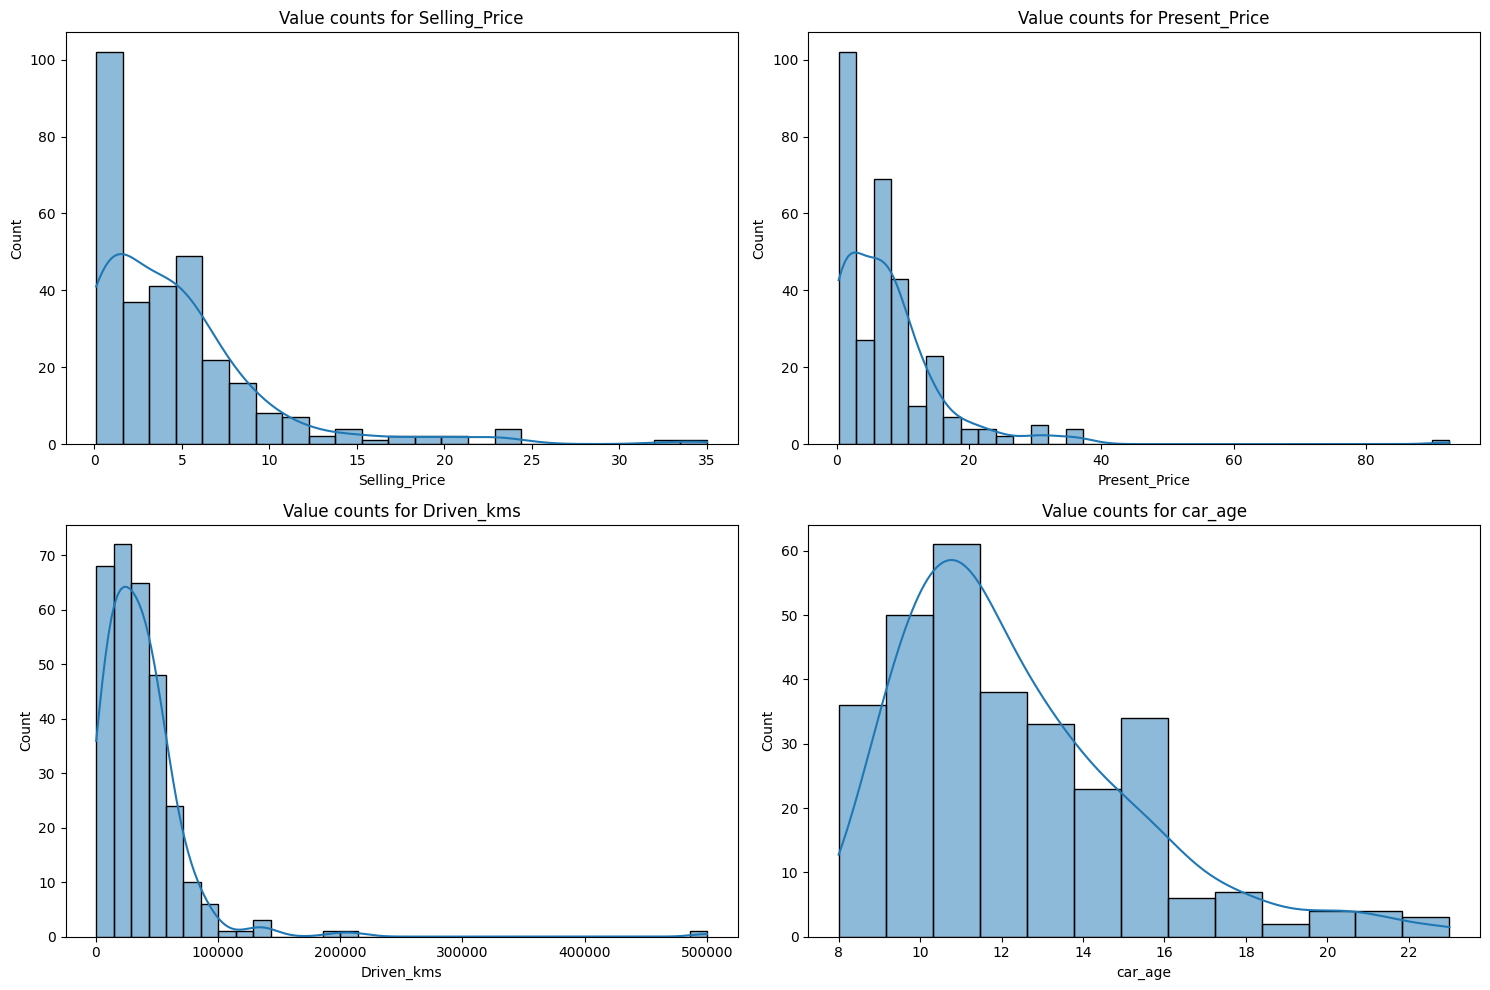

In [14]:
num_col = ['Selling_Price', 'Present_Price', 'Driven_kms', 'car_age']
def plot_value_counts(df):
    fig, axes = plt.subplots(2,2, figsize=(15,10))
    axes = axes.flatten()
    for i, col in enumerate(num_col):
        # df[col].value_counts().plot(kind='hist', ax=axes[i])
        sns.histplot(df[col], ax=axes[i], kde=True)
        axes[i].set_title(f"Value counts for {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Count")
    plt.tight_layout()
    plt.show()
plot_value_counts(df)

From the above visualizations, the following insights can be drawn:
- Selling price, present price, and drive kms are not normally distributed. Therefore, it is best to plot their box plot and look for outliers. 
- The largest number of car is 11 years old, second largest is 10 years old, followed by 12,8,16, and 13 years old.

### 2.4. Top 10 Most Selling Car

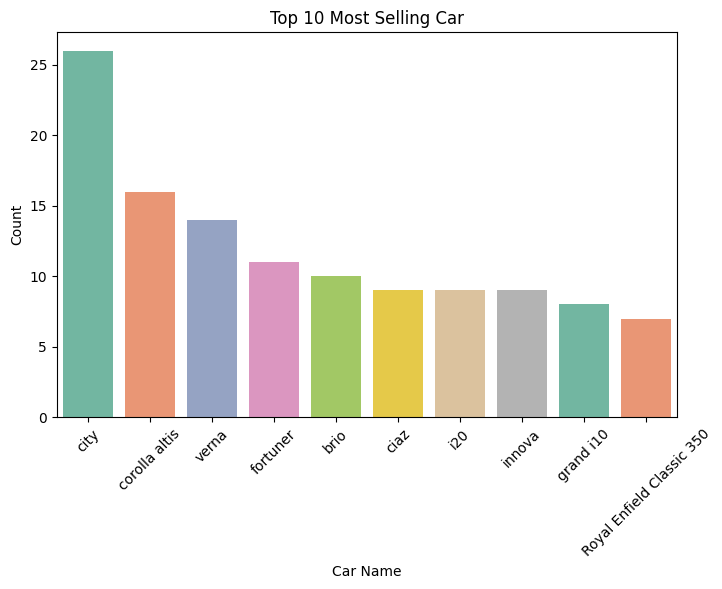

In [15]:
top10 = df['Car_Name'].value_counts().reset_index()
top10.columns = ['Car_Name', 'Count']
top10
# Create a count plot to visualize the top 10 car
plt.figure(figsize=(8, 5))
sns.barplot(x='Car_Name', y='Count', 
            data=top10.head(10), palette='Set2')
# Set labels and title for the plot
plt.xlabel('Car Name')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.title('Top 10 Most Selling Car')
# Display the plot
plt.show()


From the above chart, it is concluded that 'city' is the top most selling car, followed by corolla altis, verna, fortuner, brio, and others.

### 2.5. Number of Cars Bought Each Year

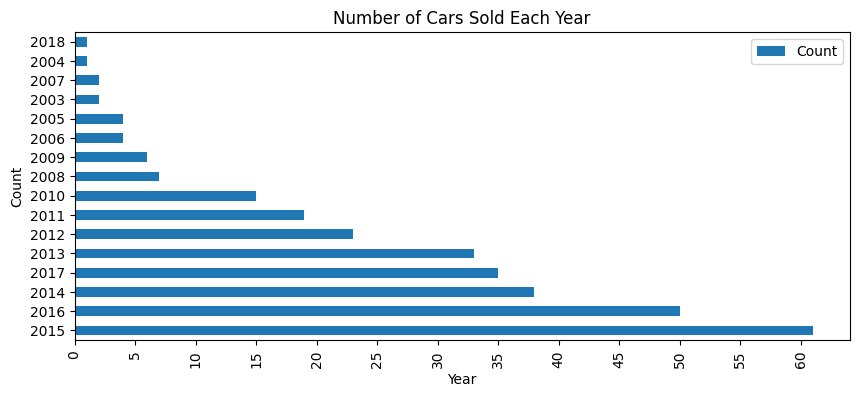

In [16]:
cnt_yearly = df.groupby('Year')['Car_Name'].count().reset_index()
cnt_yearly.columns = ['Year', 'Count']
cnt_yearly.sort_values('Count', ascending=False, inplace=True)
cnt_yearly.plot(x='Year', y='Count', kind='barh', figsize=(10,4))
plt.title("Number of Cars Sold Each Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(range(0,61,5))
plt.xticks(rotation=90)
plt.show()


### 2.6. Name and Number of Cars Bought Each Year

In [17]:
car_cnt_yearly = (df.groupby(['Year','Car_Name']).size().reset_index(name='Count'))
car_cnt_yearly.sort_values('Count', ascending=False, inplace=True)
fig = px.bar(car_cnt_yearly,x='Year',y='Count',text='Car_Name', color='Count',  # shows car names
    title="Number of Cars Sold Each Year by Car Name",
    width=900,height=1000)
fig.update_traces(textposition='inside')
fig.update_layout(xaxis=dict(title="Year",range=[2002, 2018], tickmode='linear'), 
                  coloraxis_colorbar=dict(title="Count"))
fig.show()


From the above chart, it is evident that:
- 2015 has the highest count of car purchases, followed by 2016,2014,2017 and 2013.
- The largest number of car purchased in 2015 is "City". 
- While 2004 and 2018 have the lowest count of car purchases i.e. one.

### 2.7. Categorical Variables vs Target Variable

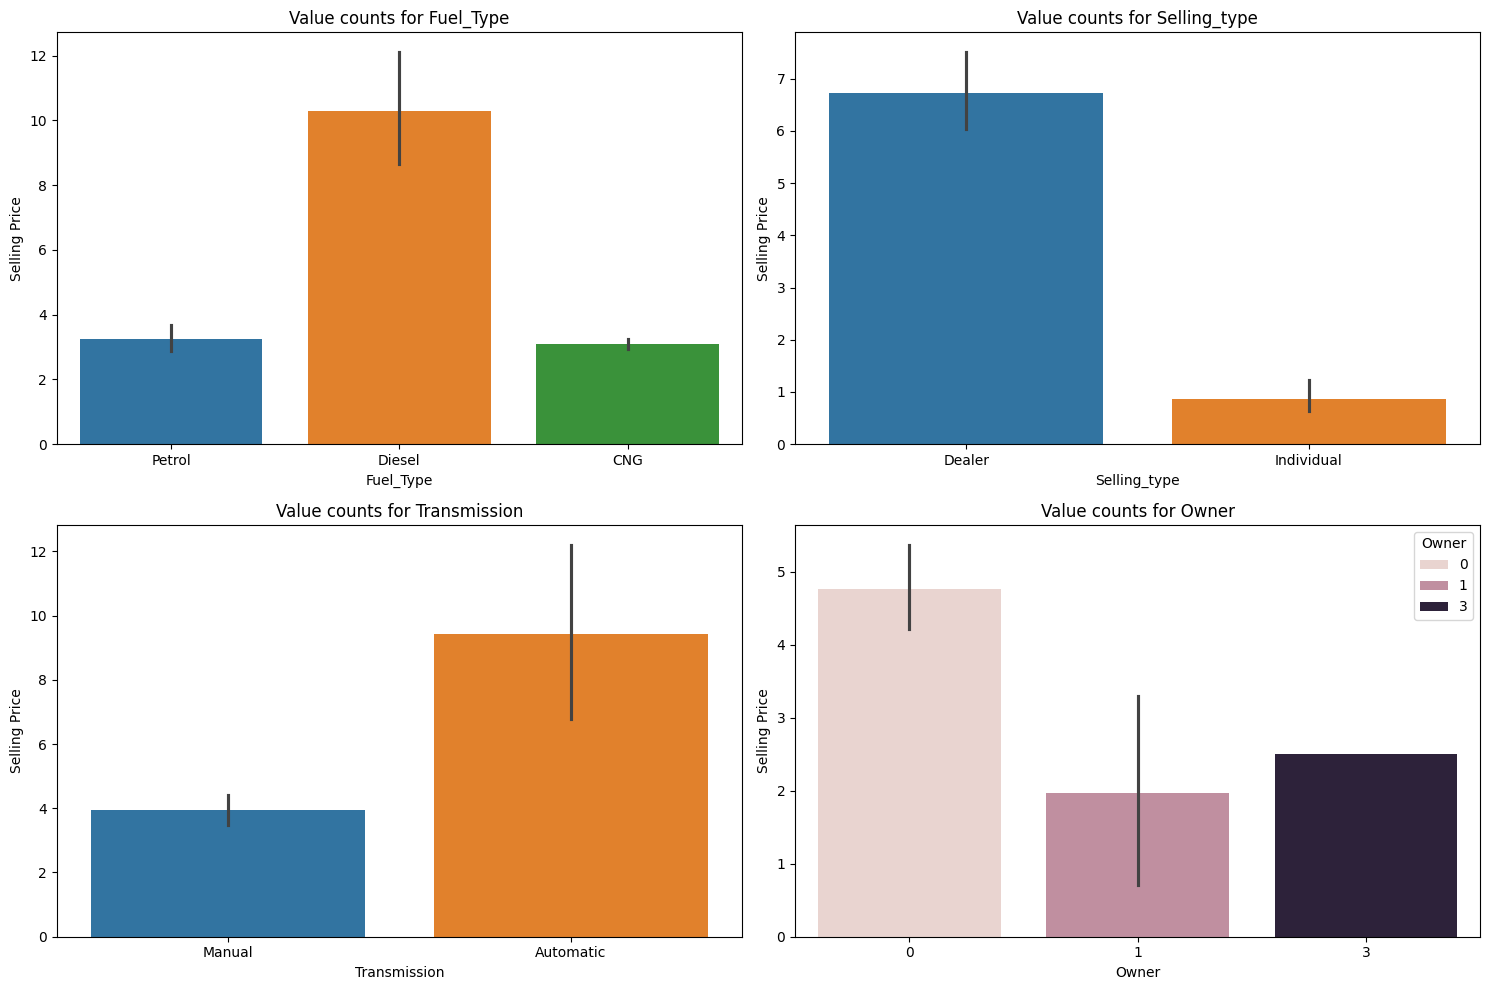

In [18]:
cat_cols = ['Fuel_Type', 'Selling_type', 'Transmission', 'Owner']
def plot_value_counts(df):
    fig, axes = plt.subplots(2, 2, figsize=(15,10))
    axes = axes.flatten()
    for i, col in enumerate(cat_cols):
        sns.barplot(data= df, x=col, y='Selling_Price', hue= col, ax=axes[i])
        axes[i].set_title(f"Value counts for {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Selling Price")
    plt.tight_layout()
    plt.show()
plot_value_counts(df)

From the above plots, I can infer the following:
- Cars with Diesel fuel type tend to have a higher Selling_Price compared to other fuel types, while Petrol and CNG cars are priced lower and are nearly similar in value.
- Vehicles sold by Dealers generally fall within a higher price range, whereas those sold by Individual sellers are typically priced lower.
- Cars with Automatic transmission are more expensive than those with Manual transmission.
- First-owner cars command a higher selling price, and the selling price gradually decreases as the number of previous owners increases.

### 2.8. Driving kms vs Target Variable

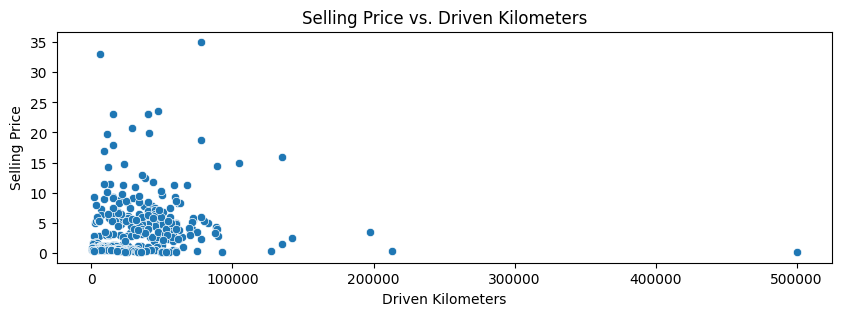

In [19]:
plt.figure(figsize=(10,3))
sns.scatterplot(data=df, x='Driven_kms', y='Selling_Price')
plt.xlabel('Driven Kilometers')
plt.ylabel('Selling Price')
plt.title('Selling Price vs. Driven Kilometers')
plt.show()

The scatter plot shows a negative correlation between Driven Kilometers and Selling Price, suggesting that higher vehicle usage is associated with lower resale value.

### 2.9. Pearson Correaltion 

In [20]:
df_conf = df.select_dtypes(include=['int64', 'float64'])
df_conf.corr()['Selling_Price'].sort_values(ascending=False)

Selling_Price    1.000000
Present_Price    0.878914
Year             0.236141
Driven_kms       0.029187
Owner           -0.088344
car_age         -0.236141
Name: Selling_Price, dtype: float64

### 2.10. Correaltion Heatmap

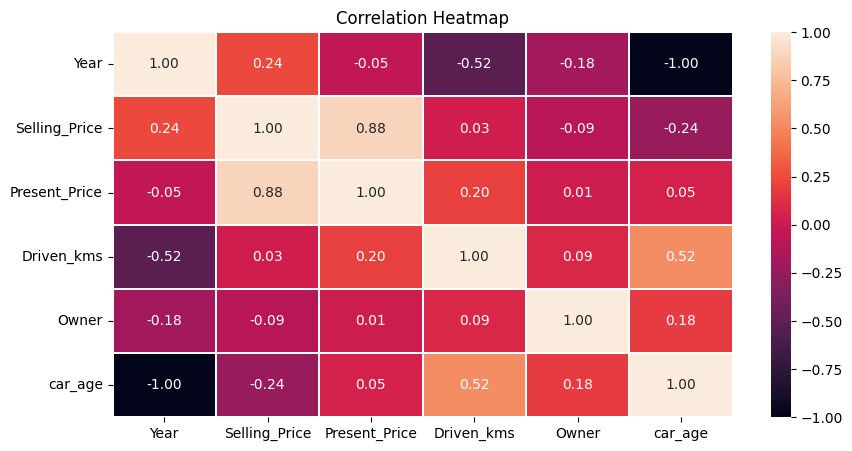

In [21]:
plt.figure(figsize=(10, 5))
sns.heatmap(df_conf.corr(), annot=True, linewidths=0.1, fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap reveals a strong positive correlation between Present_Price and Selling_Price, indicating that the current market price of a vehicle is a key predictor of its resale value. This suggests that vehicles with higher present prices tend to retain higher selling prices.

Furthermore, car_age and owner show a strong negative correlation. This inverse relationship is expected, as car_age (age of the vehicle) increases when the manufacturing Year decreases. Therefore, older vehicles tend to have higher age values and lower manufacturing years, explaining the negative correlation.

# 3. Data Pre-processing

### 3.1. Outliers Handling
    

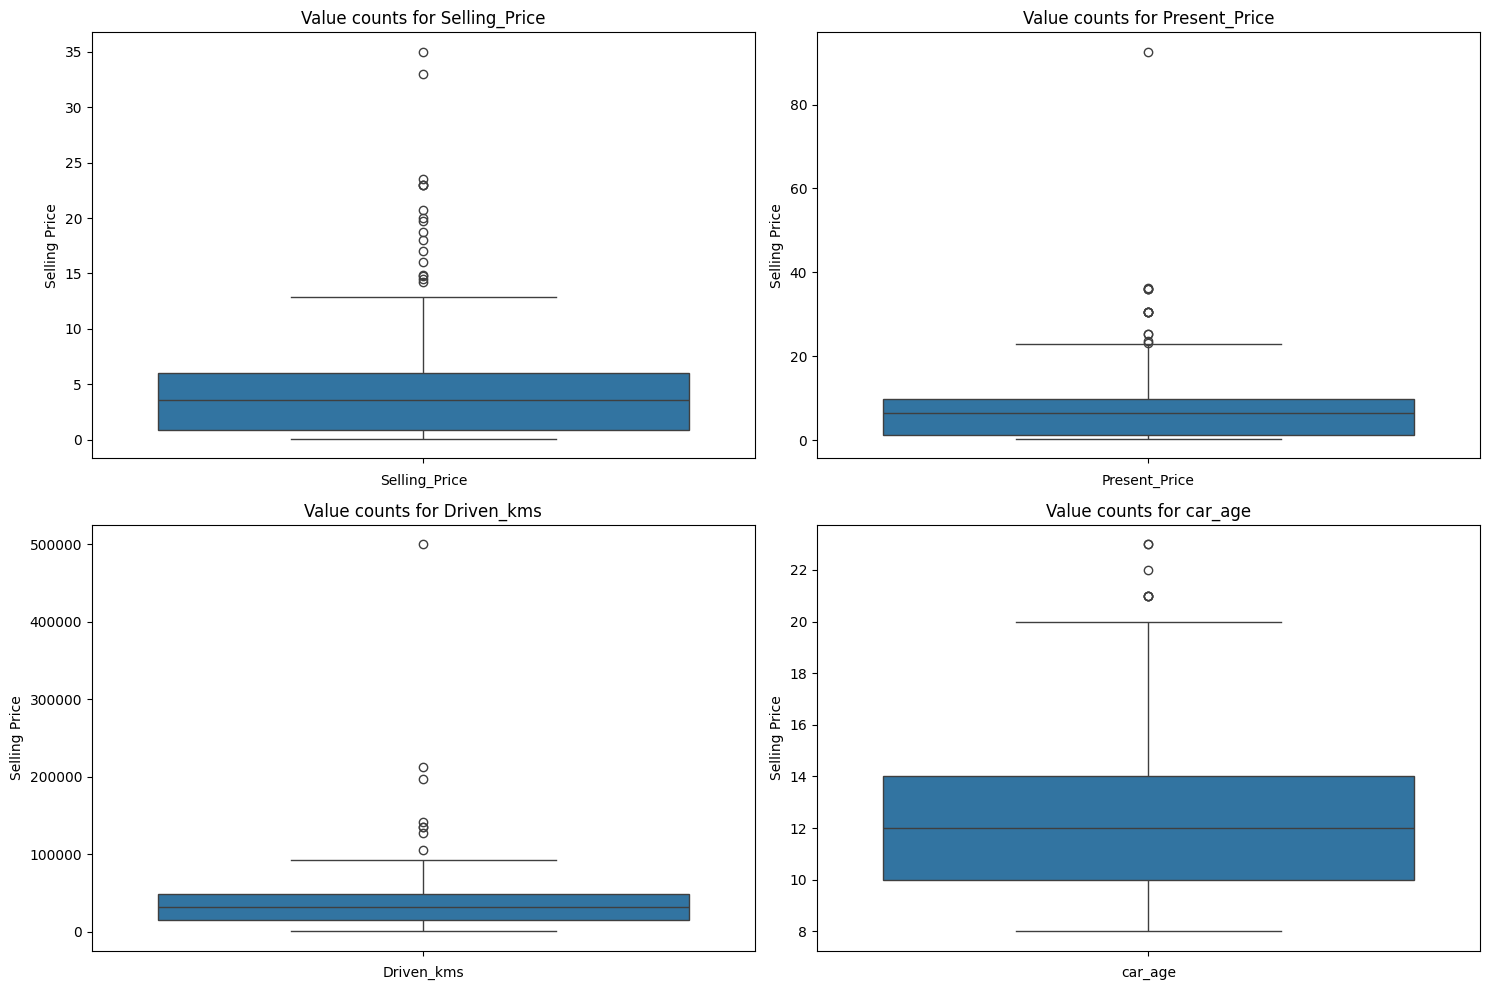

In [22]:
num_cols = ['Selling_Price', 'Present_Price', 'Driven_kms','car_age']
num_cols
def plot_value_counts(df):
    fig, axes = plt.subplots(2,2, figsize=(15,10))
    axes = axes.flatten()
    for i, col in enumerate(num_cols):
        sns.boxplot(data= df, y=col, ax=axes[i])
        axes[i].set_title(f"Value counts for {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Selling Price")
    plt.tight_layout()
    plt.show()
plot_value_counts(df)

In [23]:
# Removing outliers by Using IQR method:
Q1, Q3, median = df.Selling_Price.quantile([0.25,0.75,0.5])
lower_limit = Q1 - 1.5*(Q3-Q1)
upper_limit = Q3 + 1.5*(Q3-Q1)
df['Selling_Price'] = np.where(df['Selling_Price'] > upper_limit, median,
                               np.where(df['Selling_Price'] < lower_limit,median,df['Selling_Price']))

# Removing outliers by Capping:
for col in ['Present_Price','Driven_kms','Owner','car_age']:
  upper_limit = df[col].quantile(0.99)
  df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])
     

- In this analysis, I applied both the IQR method and the capping method to handle outliers. Using the IQR approach, I determined the upper and lower bounds for the Selling_Price and replaced the outlier values beyond these limits with the median value.
- Additionally, I performed outlier capping at the 99th percentile, where any values exceeding this threshold were replaced with the corresponding upper limit value.

### 3.2. Categorical Encoding

In [24]:
df.drop('Car_Name', axis=1, inplace=True)
df= pd.get_dummies(df)
df.head(5)

,Year,Selling_Price,Present_Price,Driven_kms,Owner,car_age,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Dealer,Selling_type_Individual,Transmission_Automatic,Transmission_Manual
0,2014,3.35,5.59,27000.0,0.0,12.0,False,False,True,True,False,False,True
1,2013,4.75,9.54,43000.0,0.0,13.0,False,True,False,True,False,False,True
2,2017,7.25,9.85,6900.0,0.0,9.0,False,False,True,True,False,False,True
3,2011,2.85,4.15,5200.0,0.0,15.0,False,False,True,True,False,False,True
4,2014,4.60,6.87,42450.0,0.0,12.0,False,True,False,True,False,False,True


### 3.3. Feature Manipulation

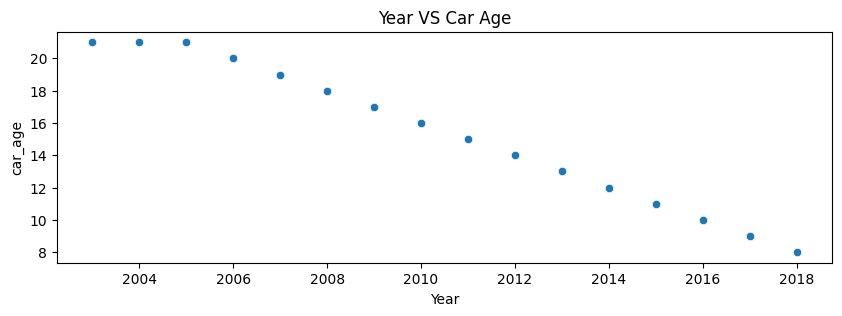

In [25]:
plt.figure(figsize=(10,3))
sns.scatterplot(x='Year',y='car_age',data=df)
plt.xlabel('Year')
plt.ylabel('car_age')
plt.title('Year VS Car Age')
plt.show()

- This graph shows the strong negative correaltion between year and car age, as with the increase in year the car_age decreases.
- Let's check its correlation using Pearson correlation technique.
  

In [26]:
df[['Year','car_age']].corr()

,Year,car_age
Year,1.000000,-0.998376
car_age,-0.998376,1.000000


- Hence, the above statement is proved correct. Now, remove the 'Year' as it is no longer needed, I have already extracted it's data in car_age.

In [27]:
df.drop('Year', axis=1, inplace=True)
df.head(5)

,Selling_Price,Present_Price,Driven_kms,Owner,car_age,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Dealer,Selling_type_Individual,Transmission_Automatic,Transmission_Manual
0,3.35,5.59,27000.0,0.0,12.0,False,False,True,True,False,False,True
1,4.75,9.54,43000.0,0.0,13.0,False,True,False,True,False,False,True
2,7.25,9.85,6900.0,0.0,9.0,False,False,True,True,False,False,True
3,2.85,4.15,5200.0,0.0,15.0,False,False,True,True,False,False,True
4,4.60,6.87,42450.0,0.0,12.0,False,True,False,True,False,False,True


### 3.4. Feature Selection

In [28]:
# Select your features wisely to avoid overfitting
fea = [i for i in df.columns if i not in ['Selling_Price']]
fea
     

['Present_Price',
 'Driven_kms',
 'Owner',
 'car_age',
 'Fuel_Type_CNG',
 'Fuel_Type_Diesel',
 'Fuel_Type_Petrol',
 'Selling_type_Dealer',
 'Selling_type_Individual',
 'Transmission_Automatic',
 'Transmission_Manual']

### 3.5. Remove Multicollinearity using VIF Technique

In [29]:
continuous_variables = ['Present_Price', 'Driven_kms', 'Owner', 'car_age']
continuous_feature_df = pd.DataFrame(df[continuous_variables])
continuous_feature_df

,Present_Price,Driven_kms,Owner,car_age
0,5.59,27000.0,0.0,12.0
1,9.54,43000.0,0.0,13.0
2,9.85,6900.0,0.0,9.0
3,4.15,5200.0,0.0,15.0
4,6.87,42450.0,0.0,12.0
...,...,...,...,...
296,11.60,33988.0,0.0,10.0
297,5.90,60000.0,0.0,11.0
298,11.00,87934.0,0.0,17.0
299,12.50,9000.0,0.0,9.0


In [30]:
def calc_vif(X):
    # Calculating VIF
    vif = pd.DataFrame()
    vif["variables"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return(vif)
calc_vif(df[[i for i in continuous_feature_df]])

,variables,VIF
0,Present_Price,2.200487
1,Driven_kms,4.389710
2,Owner,1.058084
3,car_age,4.242445


In [31]:
# Final Data
df.head()

,Selling_Price,Present_Price,Driven_kms,Owner,car_age,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Dealer,Selling_type_Individual,Transmission_Automatic,Transmission_Manual
0,3.35,5.59,27000.0,0.0,12.0,False,False,True,True,False,False,True
1,4.75,9.54,43000.0,0.0,13.0,False,True,False,True,False,False,True
2,7.25,9.85,6900.0,0.0,9.0,False,False,True,True,False,False,True
3,2.85,4.15,5200.0,0.0,15.0,False,False,True,True,False,False,True
4,4.60,6.87,42450.0,0.0,12.0,False,True,False,True,False,False,True


- I used the Pearson correlation coefficient to examine the relationships between the independent variables, as well as their correlation with the dependent variable.
- Additionally, I assessed multicollinearity among the predictors using the Variance Inflation Factor (VIF).

### 3.6. Data Transformation

Selling Price skew: 0.7570161884001796


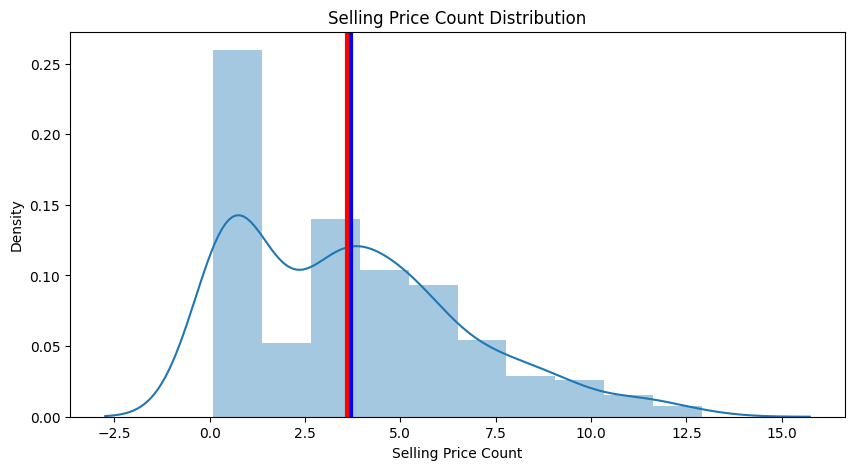

In [32]:
# Visualizing the distribution of Selling Price
plt.figure(figsize=(10,5))
sns.distplot(df["Selling_Price"])
plt.xlabel('Selling Price Count')
plt.title('Selling Price Count Distribution')
plt.axvline(df['Selling_Price'].mean(), color='blue', linestyle='solid', linewidth=3)
plt.axvline(df['Selling_Price'].median(), color='red', linestyle='solid', linewidth=3)
print("Selling Price skew:", df["Selling_Price"].skew())
plt.show()


Selling Price skew: -0.2223561302783033


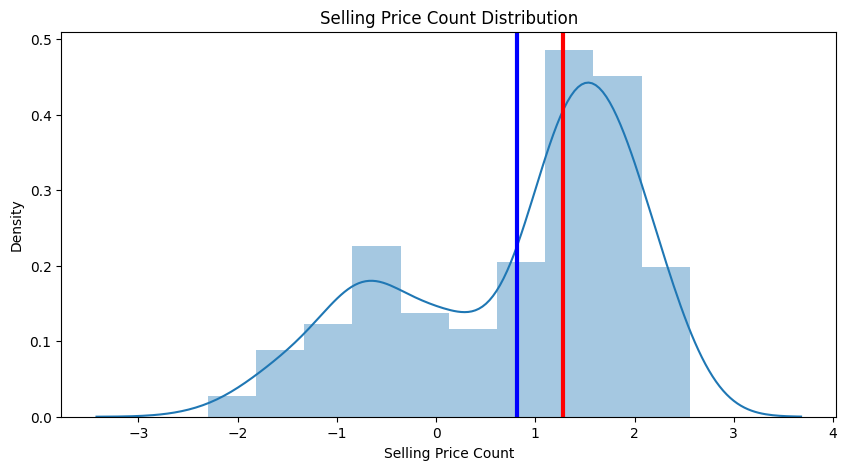

In [33]:
# Visualizing the distribution of Selling Price after Log Transformation
plt.figure(figsize=(10,5))
sns.distplot(np.log(df["Selling_Price"]))
plt.xlabel('Selling Price Count')
plt.title('Selling Price Count Distribution')
plt.axvline(np.log(df['Selling_Price']).mean(), color='blue', linestyle='solid', linewidth=3)
plt.axvline(np.log(df['Selling_Price']).median(), color='red', linestyle='solid', linewidth=3)
print("Selling Price skew:", np.log1p(df['Selling_Price']).skew())
plt.show()

- I plotted the distribution and conducted a normality test, which indicated that the data was not normally distributed and required transformation.
- After calculating the skewness, I observed that the Selling_Price variable was positively skewed. To address this, I applied a log transformation, which reduced the skewness and resulted in a distribution that is closer to normal.

### 3.6. Target Transformation (Log Transformation)

In [34]:
X = df.drop('Selling_Price',axis=1)
y = np.log(df['Selling_Price'])

### 3.7. Data Scaling

In [35]:
features = [i for i in df.columns if i not in ['Selling_Price']] 
scaler = StandardScaler()
X = scaler.fit_transform(df[features])

### 3.8. Data Splitting

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
     

# 4. Model Training & Evaluation

### 4.1. Function for Model Evaluation

In [37]:
def model_evaluation(model, y_test, y_pred):
  # Apply inverse log transformation to y_test and y_pred as,prviously used log transformation
  test_y = np.exp(y_test)
  pred_y = np.exp(y_pred)
  y_train2 = np.exp(y_train)
  y_train_pred = np.exp(model.predict(X_train))
  # Calculating Evaluation Matrix
  mse = mean_squared_error(test_y,pred_y)
  rmse = np.sqrt(mse)
  mae = mean_absolute_error(test_y,pred_y)
  r2_train = r2_score(y_train2, y_train_pred)
  r2_test = r2_score(test_y,pred_y)
  r2= 1-(1-r2_test)*((len(X_test)-1)/(len(X_test)-X_test.shape[1]-1))
  # Print results
  print("Train R2 :" ,r2_train)
  print("Test R2 :" ,r2_test)
  print("R2 : ", r2)
  print("MSE :" , mse)
  print("RMSE :" ,rmse)
  print("MAE :" ,mae)
  # plot actual and predicted values
  plt.figure(figsize=(12,4))
  plt.plot((pred_y)[:100], color='red')
  plt.plot((np.array(test_y)[:100]), color='purple')
  plt.legend(["Predicted","Actual"])
  plt.title('Actual vs Predicted Selling Price')
  try:
    imp = model.feature_importances_
  except:
    imp = model.coef_
  imp = np.absolute(imp)
  if len(imp)==len(features):
    pass
  else:
    imp = imp[0]
  # Feature importance
  fea = pd.Series(imp, index=features)
  plt.figure(figsize=(6,4))
  plt.title('Top 5 Feature Importance')
  plt.xlabel('Relative Importance')
  fea.nlargest(5).plot(kind='barh')
  model_score = [r2_train,r2_test,r2, mse,rmse,mae]
  return model_score, fea 
result = pd.DataFrame(index = ['Train R2', 'Test R2', 'R2', 'MSE', 'RMSE', 'MAE'])
fea_table = pd.DataFrame()

### 4.2. Model 1: Decision Tree Regressor

Train R2 : 1.0
Test R2 : 0.885519462867271
R2 :  0.8695791349120809
MSE : 0.9405329670329672
RMSE : 0.9698107892949878
MAE : 0.6060439560439561


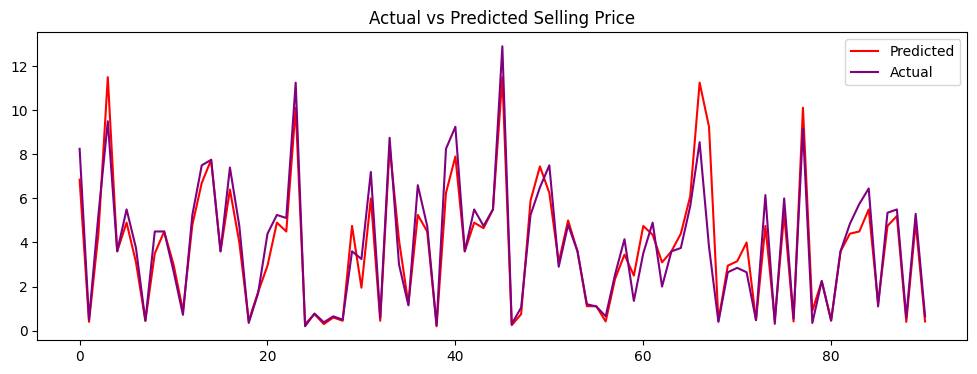

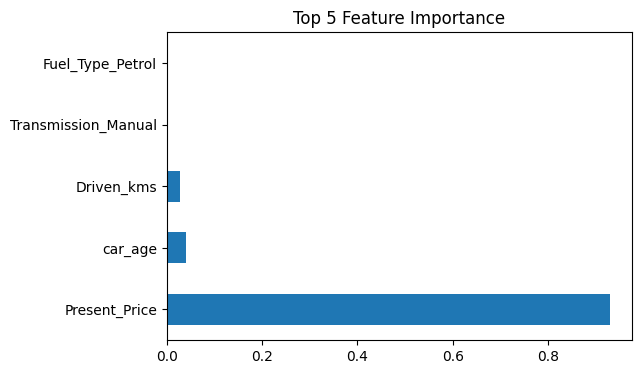

In [38]:
dt1 = DecisionTreeRegressor(random_state=1)
dt1.fit(X_train,y_train)
y_pred_dt1 = dt1.predict(X_test)
score_dt1, fea_dt1 = model_evaluation(dt1, y_test,y_pred_dt1)
result['Decision Tree'] = score_dt1
fea_table['Decision Tree'] = fea_dt1

#### 4.2.1. Cross Validation & Hyperparameter Tuning     

In [39]:
dt = DecisionTreeRegressor(random_state=1)
params = {'max_depth' : [8,10,12,14,16],
        'min_samples_split' : np.arange(35,50),
        'min_samples_leaf' : np.arange(22,31,2)}
dt_grid = GridSearchCV(dt,params,cv=6,scoring= 'neg_root_mean_squared_error')
dt_grid.fit(X_train,y_train)
dt_best_params = dt_grid.best_params_
dt_best_params

{'max_depth': 8,
 'min_samples_leaf': np.int64(24),
 'min_samples_split': np.int64(35)}

Train R2 : 0.7571346738403457
Test R2 : 0.7037801657377546
R2 :  0.6625343660303533
MSE : 2.4336409191517747
RMSE : 1.5600131150576186
MAE : 1.0866208431134632


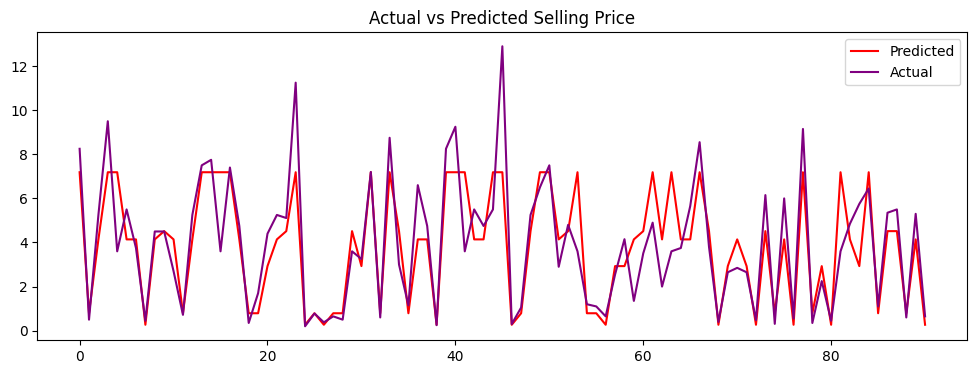

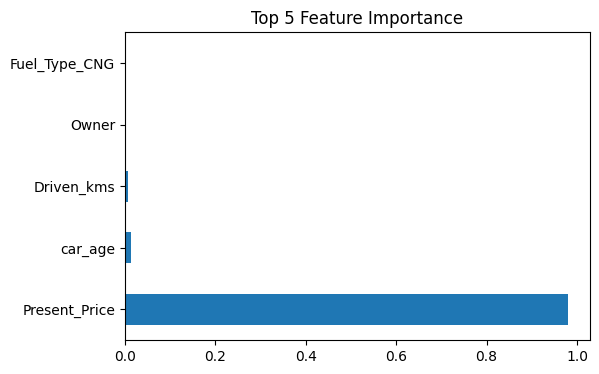

In [40]:
dt2 = DecisionTreeRegressor(max_depth=dt_best_params['max_depth'],
                                 min_samples_leaf=dt_best_params['min_samples_leaf'],
                                 min_samples_split=dt_best_params['min_samples_split'],
                                 random_state=1)
dt2.fit(X_train,y_train)
y_pred_dt2 = dt2.predict(X_test)
score_dt2, fea_dt2= model_evaluation(dt2, y_test,y_pred_dt2)
result['Tuned Decision Tree'] = score_dt2
fea_table['Tuned Decision Tree'] = fea_dt2

### 4.3. Model 2: Random Forest Regressor

Train R2 : 0.985819919691445
Test R2 : 0.923098820677053
R2 :  0.9123910615308198
MSE : 0.6317938067768527
RMSE : 0.7948545821575496
MAE : 0.5176180974463


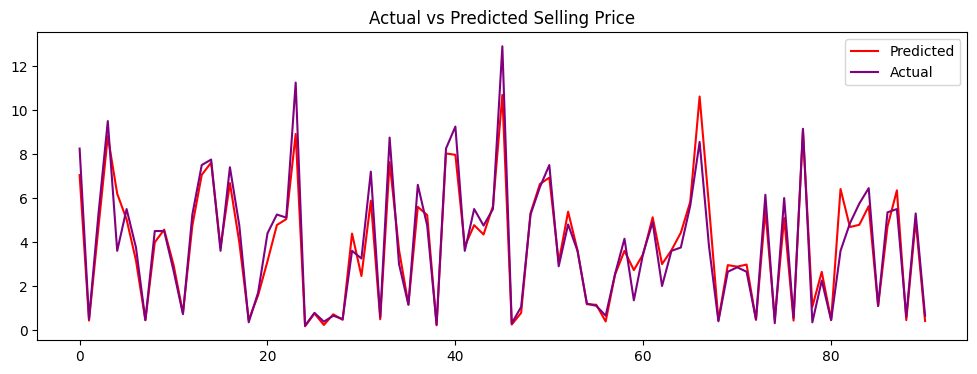

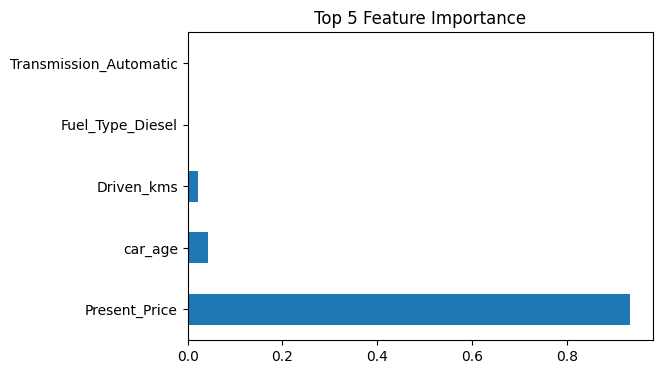

In [41]:
rf1 = RandomForestRegressor(random_state=0)
rf1.fit(X_train,y_train)
y_pred_rf1 = rf1.predict(X_test)
score_rf1, fea_rf1 = model_evaluation(rf1, y_test,y_pred_rf1)
result['Random Forest Regressor'] = score_rf1
fea_table['Random Forest'] = fea_rf1

#### 4.3.1. Cross Validation & Hyperparameter Tuning

In [42]:
rf = RandomForestRegressor(random_state=0)
rf_params = {'n_estimators':[300],                    
             'min_samples_leaf':np.arange(20,25)}    
rf_grid= GridSearchCV(rf,rf_params,cv=6,scoring='neg_root_mean_squared_error')
rf_grid.fit(X_train,y_train)
rf_best_params = rf_grid.best_params_
rf_best_params

{'min_samples_leaf': np.int64(20), 'n_estimators': 300}

Train R2 : 0.7663595338428182
Test R2 : 0.7317755423155876
R2 :  0.694427833017758
MSE : 2.2036404731770425
RMSE : 1.4844663934144964
MAE : 1.0271615986529425


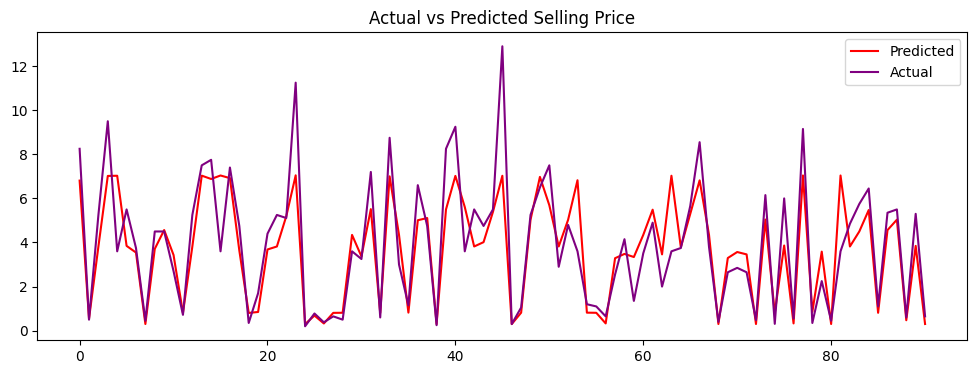

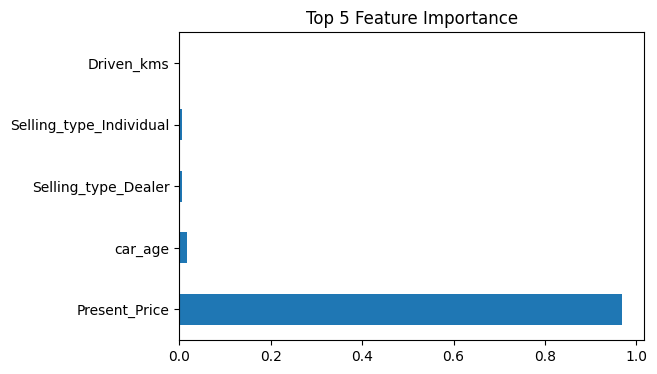

In [43]:
rf2= RandomForestRegressor(n_estimators=rf_best_params['n_estimators'],
                                 min_samples_leaf=rf_best_params['min_samples_leaf'],
                                 random_state=0)
rf2.fit(X_train,y_train)  
y_pred_rf2 = rf2.predict(X_test)
score_rf2, fea_rf2 = model_evaluation(rf2, y_test,y_pred_rf2)
result['Tuned Random Forest'] = score_rf2
fea_table['Tuned Random Forest'] = fea_rf2

### 4.4. Model 3: Gradient Boosting Regressor

Train R2 : 0.9812650821012618
Test R2 : 0.9082001411761742
R2 :  0.8954178823526036
MSE : 0.754196265629647
RMSE : 0.8684447395370917
MAE : 0.5524692595063979


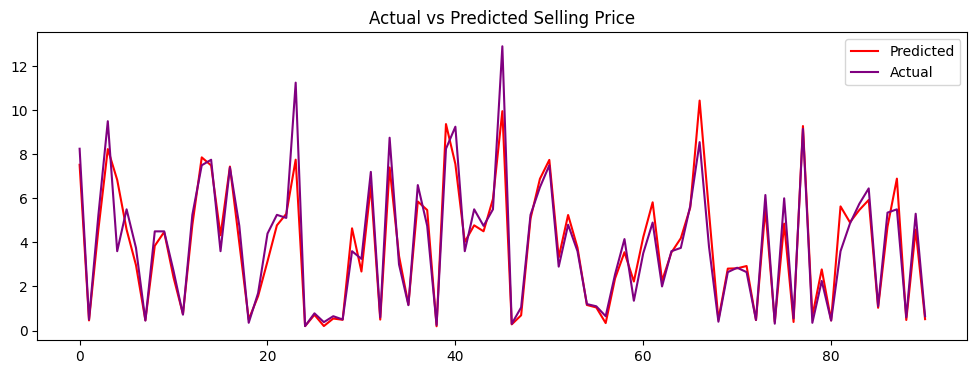

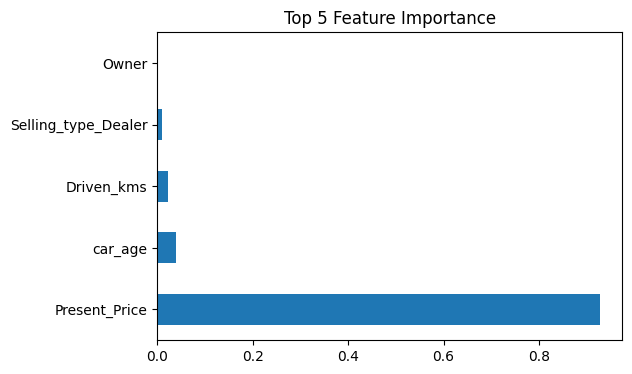

In [44]:
gb1 = GradientBoostingRegressor(random_state=0)
gb1.fit(X_train,y_train)
y_pred_gb1 = gb1.predict(X_test)
score_gb1, fea_gb1 = model_evaluation(gb1, y_test,y_pred_gb1)
result['Gradient Boosting Regressor'] = score_gb1
fea_table['Gradient Boosting Regressor'] = fea_gb1

#### 4.4.1. Cross Validation & Hyperparameter Tuning

In [45]:
gb = GradientBoostingRegressor(random_state=0)
gb_params = {'n_estimators':[300],
             'min_samples_leaf':np.arange(20,24),
             'max_depth':np.arange(14,17)
             }
gb_random = RandomizedSearchCV(gb, param_distributions=gb_params, cv=6, n_iter=20, 
                               scoring='neg_root_mean_squared_error', n_jobs=-1)
gb_random.fit(X_train, y_train)
gb_best_params = gb_random.best_params_
gb_best_params

{'n_estimators': 300,
 'min_samples_leaf': np.int64(21),
 'max_depth': np.int64(14)}

Train R2 : 0.959743103932394
Test R2 : 0.8386893730027576
R2 :  0.8162283996233948
MSE : 1.3252729802251233
RMSE : 1.1512050122480892
MAE : 0.6787811798541177


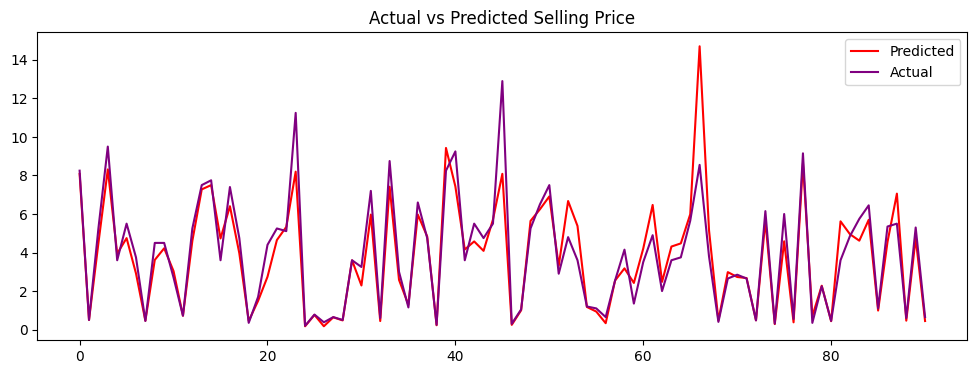

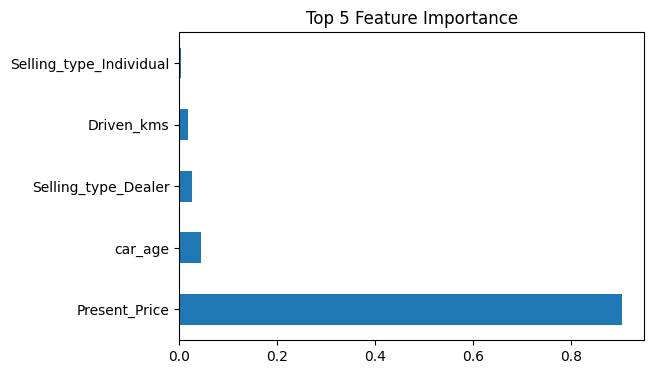

In [46]:
gb2 = GradientBoostingRegressor(n_estimators=gb_best_params['n_estimators'],
                                     min_samples_leaf=gb_best_params['min_samples_leaf'],
                                     max_depth = gb_best_params['max_depth'],
                                     random_state=0)
gb2.fit(X_train,y_train)
y_pred_gb2 = gb2.predict(X_test)
score_gb2, fea_gb2 = model_evaluation(gb2, y_test,y_pred_gb2)
result['Tuned Gradient Boosting'] = score_gb2
fea_table['Tuned Gradient Boosting'] = fea_gb2

### 4.5. Model 4: XGBoost Regressor

Train R2 : 0.9999862917811613
Test R2 : 0.9244986062264628
R2 :  0.9139857539288817
MSE : 0.6202936471080527
RMSE : 0.7875872314277655
MAE : 0.5049292874532743


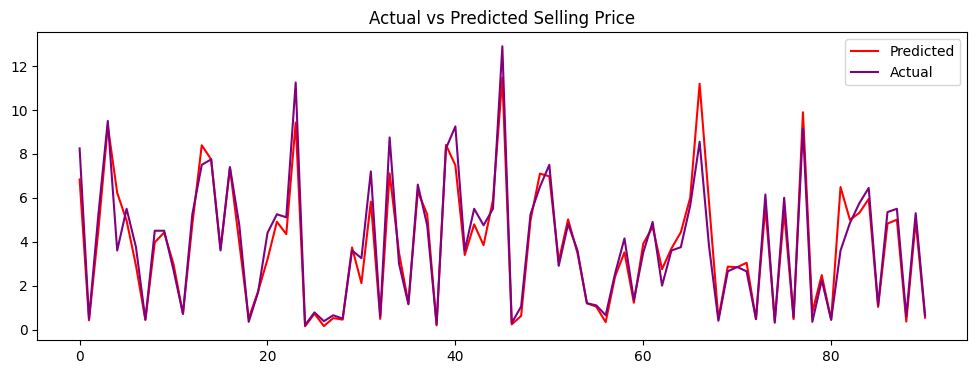

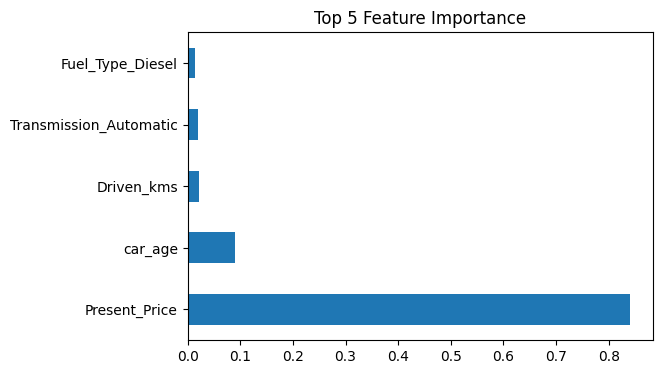

In [47]:
xgb1 = XGBRegressor(random_state=0,objective='reg:squarederror')
xgb1.fit(X_train,y_train)
y_pred_xgb1 = xgb1.predict(X_test)
score_xgb1, fea_xgb1= model_evaluation(xgb1, y_test,y_pred_xgb1)
result['XGBoost Regressor'] = score_xgb1
fea_table['XGBoost Regressor'] = fea_xgb1

#### 4.5.1. Cross Validation & Hyperparameter Tuning

In [48]:
xgb = XGBRegressor(random_state=0,objective='reg:squarederror')
xgb_params = {'n_estimators':[500],
             'min_samples_leaf':np.arange(20,22)}  
xgb_search = RandomizedSearchCV(xgb,xgb_params,cv=6,scoring='neg_root_mean_squared_error',
                                n_iter=100, n_jobs=-1)
xgb_search.fit(X_train,y_train)
xgb_best_params = xgb_search.best_params_
xgb_best_params

{'n_estimators': 500, 'min_samples_leaf': np.int64(20)}

Train R2 : 0.9999862922243313
Test R2 : 0.9244986610475718
R2 :  0.9139858163833097
MSE : 0.620293196716557
RMSE : 0.7875869454965319
MAE : 0.5049287539589538


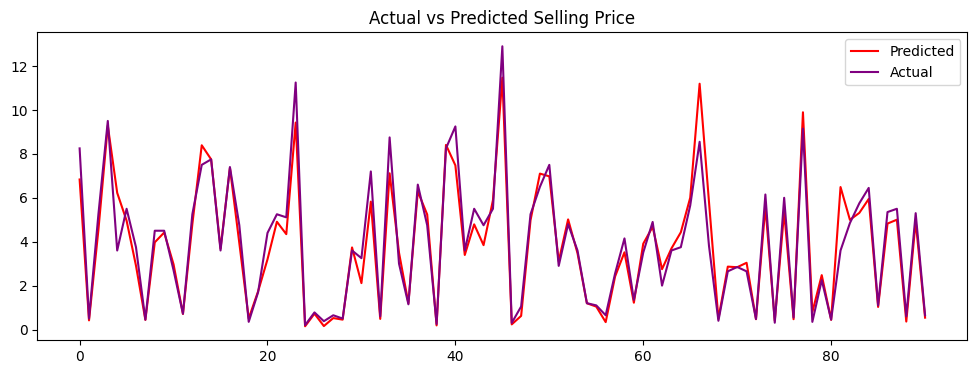

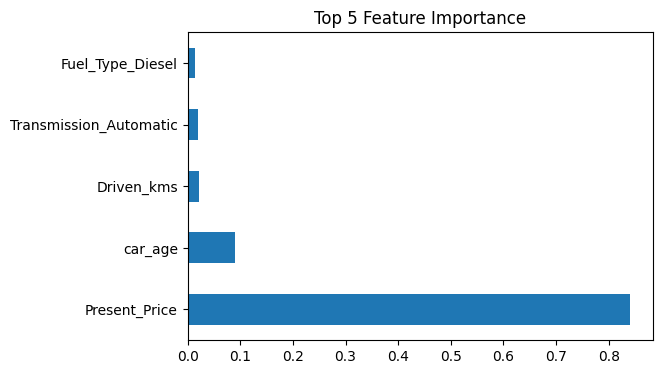

In [49]:
xgb2 = XGBRegressor(n_estimators=xgb_best_params['n_estimators'],
                             min_samples_leaf=xgb_best_params['min_samples_leaf'],
                             random_state=0)
xgb2.fit(X_train,y_train)
y_pred_xgb2 = xgb2.predict(X_test)
score_xgb2, fea_xgb2= model_evaluation(xgb2, y_test,y_pred_xgb2)
result['Tuned XGBoost Regressor'] = score_xgb2
fea_table['Tuned XGBoost Regressor'] = fea_xgb2

### 4.6. Model Performance Table

In [50]:
result

,Decision Tree,Tuned Decision Tree,Random Forest Regressor,Tuned Random Forest,Gradient Boosting Regressor,Tuned Gradient Boosting,XGBoost Regressor,Tuned XGBoost Regressor
Train R2,1.000000,0.757135,0.985820,0.766360,0.981265,0.959743,0.999986,0.999986
Test R2,0.885519,0.703780,0.923099,0.731776,0.908200,0.838689,0.924499,0.924499
R2,0.869579,0.662534,0.912391,0.694428,0.895418,0.816228,0.913986,0.913986
MSE,0.940533,2.433641,0.631794,2.203640,0.754196,1.325273,0.620294,0.620293
RMSE,0.969811,1.560013,0.794855,1.484466,0.868445,1.151205,0.787587,0.787587
MAE,0.606044,1.086621,0.517618,1.027162,0.552469,0.678781,0.504929,0.504929


- Based on the comparative analysis of all developed models, the R² score was chosen as the primary evaluation metric. The R² metric effectively measures the proportion of variance in the dependent variable that is explained by the independent variables. As such, it serves as a reliable indicator for assessing model performance and overall feasibility.

In [51]:
results = result.T
results.index.name = "Models"
results = results.sort_values(by="Test R2", ascending=False)
results

,Train R2,Test R2,R2,MSE,RMSE,MAE
Models,,,,,,
Tuned XGBoost Regressor,0.999986,0.924499,0.913986,0.620293,0.787587,0.504929
XGBoost Regressor,0.999986,0.924499,0.913986,0.620294,0.787587,0.504929
Random Forest Regressor,0.985820,0.923099,0.912391,0.631794,0.794855,0.517618
Gradient Boosting Regressor,0.981265,0.908200,0.895418,0.754196,0.868445,0.552469
Decision Tree,1.000000,0.885519,0.869579,0.940533,0.969811,0.606044
Tuned Gradient Boosting,0.959743,0.838689,0.816228,1.325273,1.151205,0.678781
Tuned Random Forest,0.766360,0.731776,0.694428,2.203640,1.484466,1.027162
Tuned Decision Tree,0.757135,0.703780,0.662534,2.433641,1.560013,1.086621


### 4.7. Models Performance Visualisation

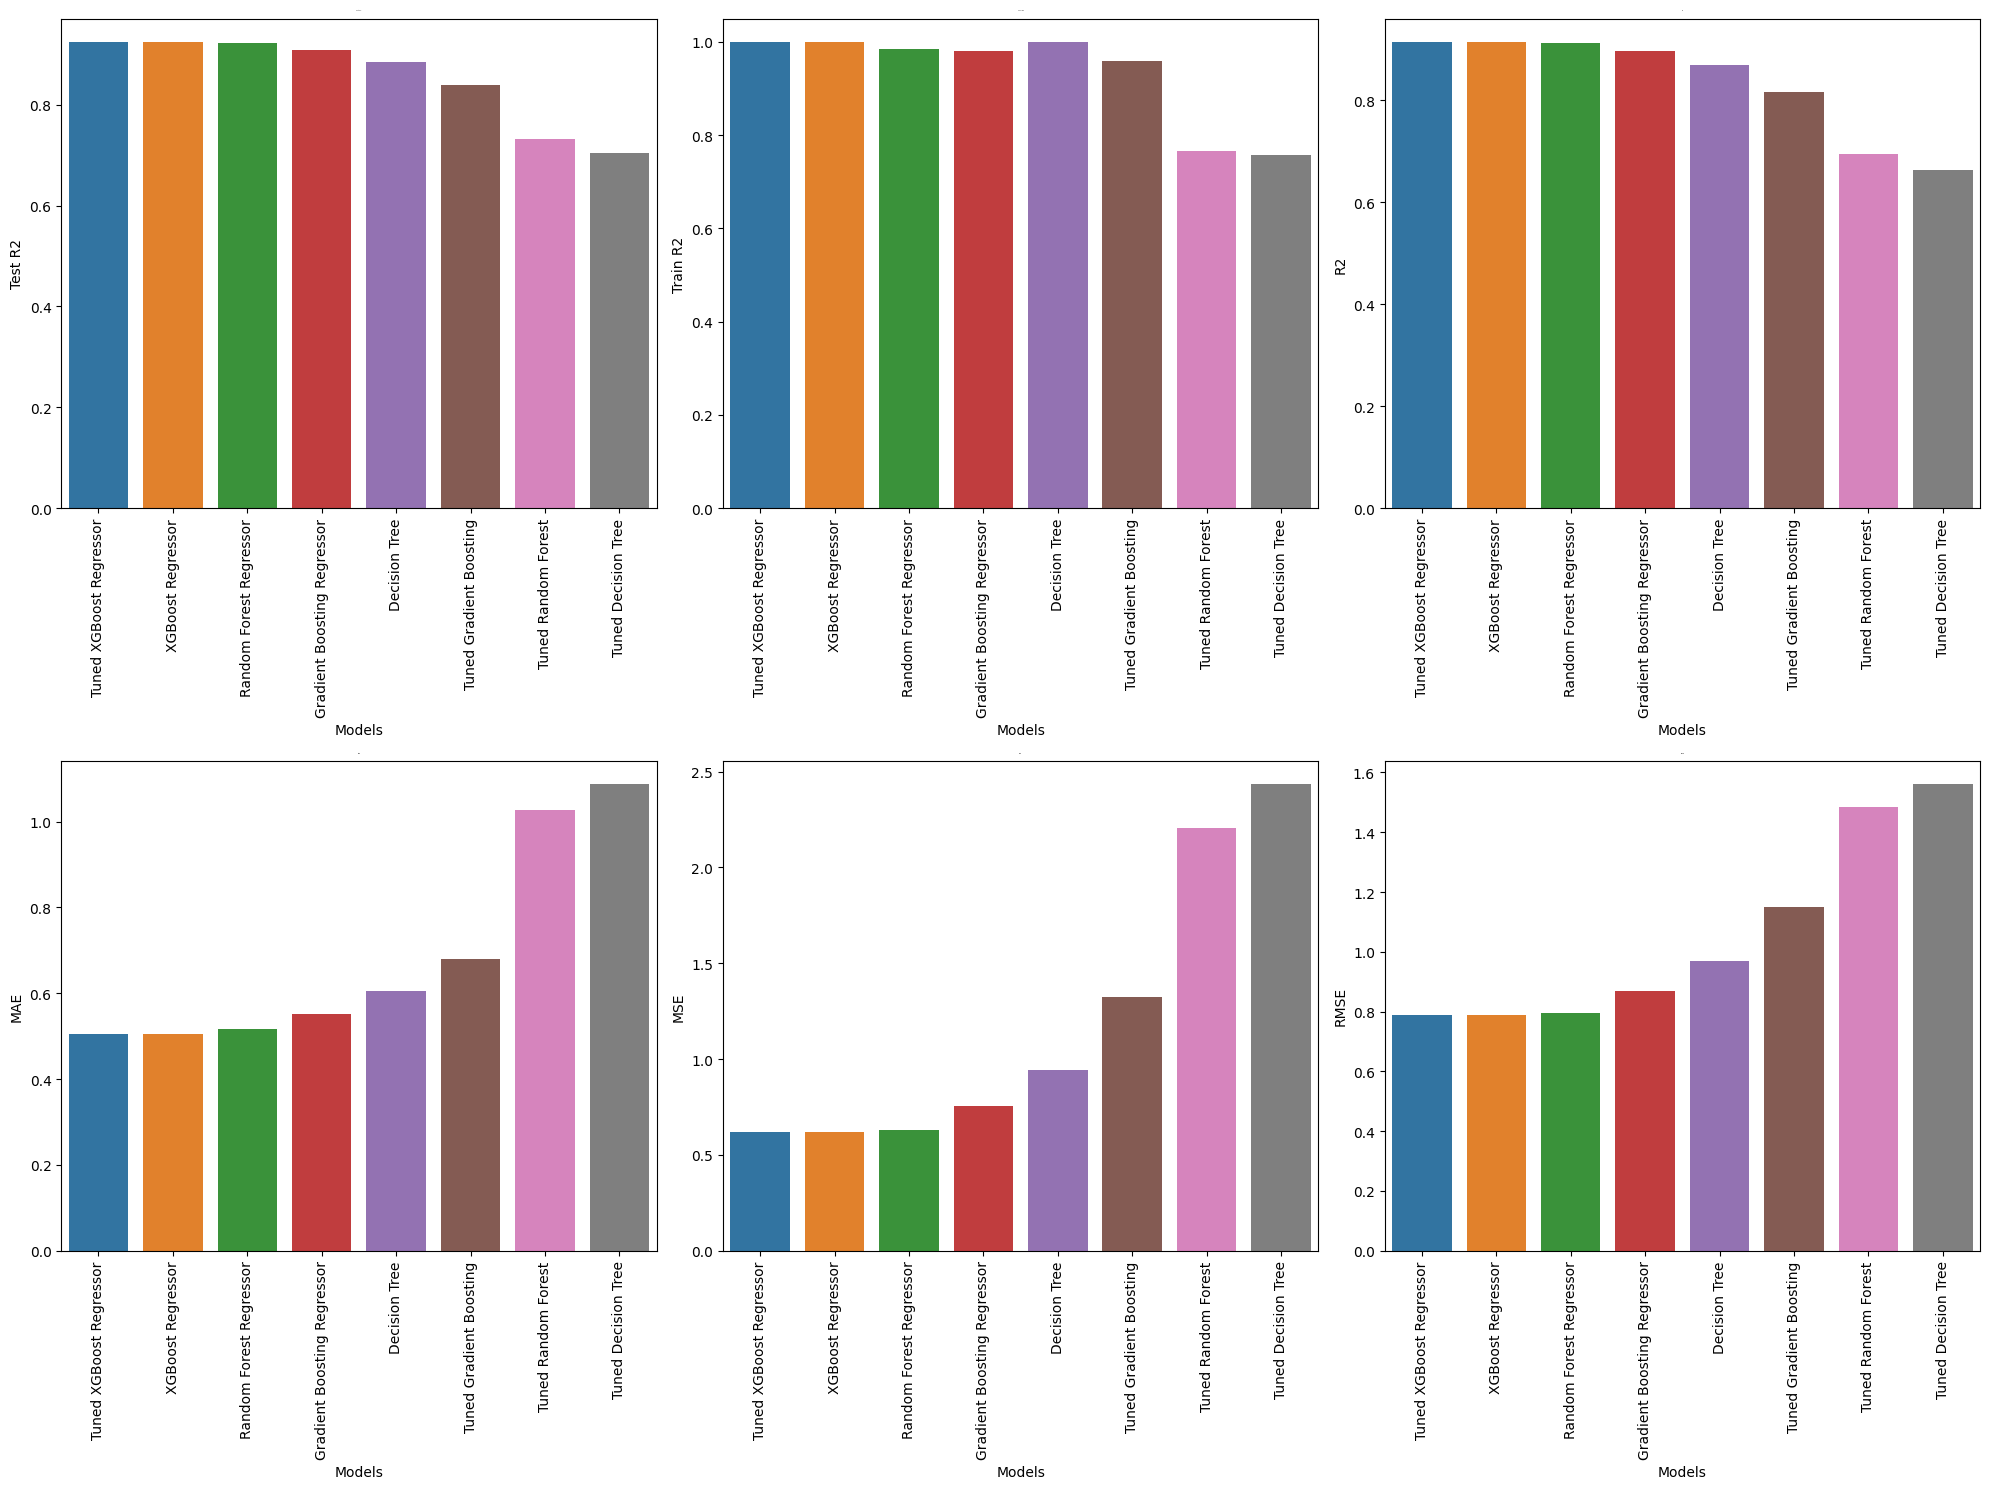

In [52]:
metrics = ['Test R2','Train R2','R2','MAE','MSE','RMSE']
fig, ax = plt.subplots(2, 3, figsize=(20,15))
# plt.subplots_adjust(hspace=1.0, wspace=0.8)
ax = ax.flatten()
for i, metric in enumerate(metrics):
    sns.barplot(data=results, x="Models", y=metric, ax=ax[i], hue= "Models")
    plt.subplots_adjust(hspace=1.0, wspace=0.8)
    ax[i].set_title(metric, fontsize=0)
    ax[i].tick_params(axis='x', rotation=90)   
    ax[i].set_xlabel("Models")                     

plt.tight_layout()
plt.show()

### 4.8. Feature Importance Table

In [53]:
feature = fea_table.T
feature.index.name = "Features"
feature

,Present_Price,Driven_kms,Owner,car_age,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Dealer,Selling_type_Individual,Transmission_Automatic,Transmission_Manual
Features,,,,,,,,,,,
Decision Tree,0.929275,0.027763,0.000003,0.039994,0.000002,0.000197,0.000637,0.000000,0.000010,0.000197,0.001923
Tuned Decision Tree,0.979717,0.006542,0.000000,0.013741,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Random Forest,0.933720,0.021099,0.000386,0.042096,0.000014,0.000830,0.000569,0.000235,0.000114,0.000581,0.000357
Tuned Random Forest,0.968295,0.002010,0.000000,0.018030,0.000000,0.000000,0.000019,0.005867,0.005778,0.000000,0.000000
Gradient Boosting Regressor,0.928538,0.021560,0.000548,0.039329,0.000022,0.000548,0.000005,0.008901,0.000269,0.000106,0.000175
Tuned Gradient Boosting,0.903344,0.018252,0.000000,0.044025,0.000000,0.002770,0.000773,0.026361,0.003687,0.000510,0.000280
XGBoost Regressor,0.841280,0.021229,0.006038,0.090370,0.000011,0.014647,0.000140,0.006591,0.000000,0.019693,0.000000
Tuned XGBoost Regressor,0.841280,0.021229,0.006038,0.090370,0.000011,0.014647,0.000140,0.006591,0.000000,0.019693,0.000000


- 'Present_Price' is the common and most important feature among all the models followed by 
'car_age' , and  'Driven_kms'.

# 5. Saving the Models

In [57]:
Path("trained_models").mkdir(exist_ok=True)
joblib.dump(xgb2, 'trained_models/tuned_xgb.joblib')
joblib.dump(xgb1, 'trained_models/xgb_model.joblib')
joblib.dump(rf1, 'trained_models/rf_model.joblib')
joblib.dump(gb1, 'trained_models/gb_model.joblib')
joblib.dump(dt1, 'trained_models/dt_model.joblib')

['trained_models/dt_model.joblib']

# 6. Conclusion 

- Multiple machine learning algorithms are implemented and evaluated, including Decision Tree, Random Forest, Gradient Boosting, and Extreme Gradient Boosting. After thorough evaluation, Tuned Extreme Gradient Boosting is selected as the final prediction model.
-  Tuned Extreme Gradient Boosting model achieved 99% training accuracy and 92% testing accuracy, indicating strong predictive capability and good generalization performance. In comparison, certain other models demonstrated overfitting, characterized by high training accuracy but relatively lower testing performance.
- Given its balanced performance across both training and testing datasets, along with its ability to reduce overfitting through ensemble learning, the Tuned Extreme Gradient Boosting model is determined to be the most appropriate choice for future deployment.